# SuppFig — SV / indel late timing vs SBS3
Panels b (LOH score vs $\pi^{SBS3}_{late}$) and d ($\pi^{ID6+ID8}_{late}$ vs $\pi^{SBS3}_{late}$) for PCAWG breast HRD-WGD cancers.
All values are read from the supplementary tables.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import pearsonr

import matplotlib as mpl
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "font.family": "sans-serif", "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.25,
    "xtick.major.width": 0.25, "ytick.major.width": 0.25,
    "xtick.minor.width": 0.25, "ytick.minor.width": 0.25,
    "xtick.labelsize": 7, "ytick.labelsize": 7,
})

def nature_axes(ax, keep_top=False):
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(keep_top)
    for sp in ax.spines.values():
        sp.set_linewidth(0.25)
    ax.tick_params(width=0.25)
    return ax

SV_TABLE = '../supplemental_tables_v2/SupTable4_SV_pi_late.xlsx'
ID_TABLE = '../supplemental_tables_v2/SupTable5_ID6_ID8_pi_late.xlsx'
OUT_DIR = '../output/SuppFig_SV_Indel_pi_late'

import os
os.makedirs(OUT_DIR, exist_ok=True)

In [2]:
sv = pd.read_excel(SV_TABLE, sheet_name='SV pi_late')
idt = pd.read_excel(ID_TABLE, sheet_name='ID6_ID8 pi_late')

In [3]:
def scatter_fit(x, y, xlabel, ylabel, title, out, ylim=None):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    r, p = pearsonr(x, y)
    fig, ax = plt.subplots(figsize=(3.2, 3.2))
    ax.scatter(x, y, color='k', s=16, zorder=20)
    model = sm.OLS(y, sm.add_constant(x)).fit()
    xp = np.linspace(0, 1, 100)
    pred = model.get_prediction(sm.add_constant(xp)).summary_frame(alpha=0.05)
    ax.plot(xp, pred['mean'], 'k-', linewidth=0.8)
    ax.fill_between(xp, pred['mean_ci_lower'], pred['mean_ci_upper'], color='grey', alpha=0.2)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.text(0.03, 0.95, f'r = {r:.2f}\np = {p:.1e}', transform=ax.transAxes,
            va='top', ha='left', fontsize=8)
    nature_axes(ax)
    fig.tight_layout()
    fig.savefig(out, format='pdf', bbox_inches='tight')
    plt.show()
    return model, r, p

### Panel b — LOH score vs $\pi^{SBS3}_{late}$

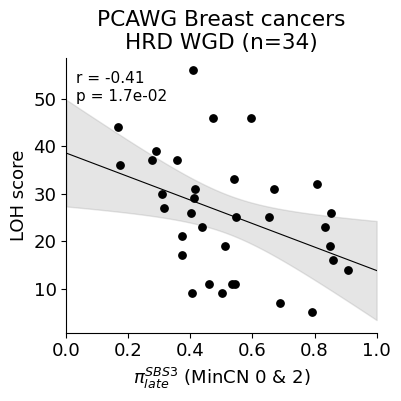

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7efab0909270>,
 np.float64(-0.40551307235027284),
 np.float64(0.017344634713475755))

In [4]:
b = sv[['pi_late_SBS3', 'LOH_score']].dropna()
scatter_fit(b['pi_late_SBS3'], b['LOH_score'],
            r'$\pi^{SBS3}_{late}$ (MinCN 0 & 2)', 'LOH score',
            f'PCAWG Breast cancers\nHRD WGD (n={len(b)})',
            f'{OUT_DIR}/panelB_LOHscore_vs_piSBS3.pdf')

### Panel d — $\pi^{ID6+ID8}_{late}$ vs $\pi^{SBS3}_{late}$

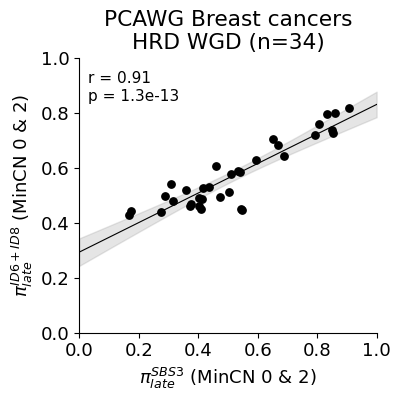

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7efaa823b5b0>,
 np.float64(0.9077469587641755),
 np.float64(1.2982012266447139e-13))

In [5]:
d = idt[['pi_late_SBS3', 'pi_late_ID6_ID8']].dropna()
scatter_fit(d['pi_late_SBS3'], d['pi_late_ID6_ID8'],
            r'$\pi^{SBS3}_{late}$ (MinCN 0 & 2)',
            r'$\pi^{ID6+ID8}_{late}$ (MinCN 0 & 2)',
            f'PCAWG Breast cancers\nHRD WGD (n={len(d)})',
            f'{OUT_DIR}/panelD_piID6ID8_vs_piSBS3.pdf', ylim=(0, 1))

### $\pi^{SV}_{late}$ vs $\pi^{SBS3}_{late}$

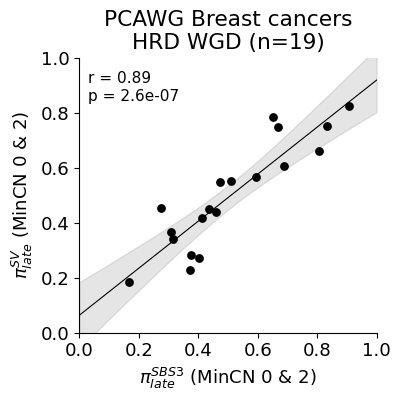

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7efaa7b8ea40>,
 np.float64(0.8934617097444395),
 np.float64(2.594903787434469e-07))

In [6]:
s = sv[['pi_late_SBS3', 'pi_late_SV']].dropna()
scatter_fit(s['pi_late_SBS3'], s['pi_late_SV'],
            r'$\pi^{SBS3}_{late}$ (MinCN 0 & 2)',
            r'$\pi^{SV}_{late}$ (MinCN 0 & 2)',
            f'PCAWG Breast cancers\nHRD WGD (n={len(s)})',
            f'{OUT_DIR}/panel_piSV_vs_piSBS3.pdf', ylim=(0, 1))